In [225]:
# IPython magig  tools
%load_ext autoreload
%autoreload 2

from os import PathLike
import os

from aind_vr_foraging_analysis.utils.parsing import parse, data_access
import aind_vr_foraging_analysis.utils.plotting as plotting

# Plotting libraries
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import seaborn as sns
import pandas as pd
import numpy as np
import pytz
from datetime import datetime
sns.set_context('talk')

import warnings
pd.options.mode.chained_assignment = None  # Ignore SettingWithCopyWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

color1='#d95f02'
color2='#1b9e77'
color3='#7570b3'
color4='yellow'
odor_list_color = [color1, color2, color3, color4]

color_dict_label = {'InterSite': '#808080',
    'InterPatch': '#b3b3b3', 'PatchZ': '#d95f02',
    'PatchZA': '#d95f02', 'PatchZB': '#d95f02', 
    'PatchB': '#d95f02','PatchA': '#7570b3', 
    'PatchC': '#1b9e77',
    'Alpha-pinene': '#1b9e77', 
    'Methyl Butyrate': '#7570b3', 
    'Amyl Acetate': '#d95f02', 
    'Fenchone': '#7570b3', 
    'Dipropyl sulfide': '#7570b3',
    'Dypropil sulfide': '#7570b3',
    'Hexanal': '#1b9e77',
    'Pentyl acetate': '#d95f02',
    'S': color1,
    'D': color2,
    'N': color3,   
    'Do': color1,
    'None': color4, 
    'odor_0': color3,
    'odor_60': color2,
    'odor_90': color1,
    'odor_fast': '#d95f02',
    'odor_slow': '#1b9e77',
    'A': color1,
    'B': color2,
    'C': color3,
    'OdorA': color1,
    'OdorB': color2,
    'OdorC': color3,
    }

label_dict = {
    **{"InterSite": '#808080', "InterPatch": '#b3b3b3'}, 
    **color_dict_label
}

pdf_path = r'Z:\scratch\vr-foraging\sessions'
base_path = 'Z:/scratch/vr-foraging/data/'
foraging_figures = r'C:\Users\jason.lee\OneDrive - Allen Institute\Documents\patch_foraging\VR_FIP'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [226]:
#Session picker
from pathlib import Path

#session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-19T234013Z")
#session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-17T232028Z")
#session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-15T231441Z")
#session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-12T231442Z")
#session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-11T194307Z")
#session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-10T235940Z")
#session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-09T191007Z")

#session_path = Path(r"Y:\vr-foraging\data\810351\810351_2025-12-20T002820Z")
#session_path = Path(r"Y:\vr-foraging\data\810351\810351_2025-12-18T000750Z")
#session_path = Path(r"Y:\vr-foraging\data\810351\810351_2025-12-16T000745Z")
#session_path = Path(r"Y:\vr-foraging\data\810351\810351_2025-12-13T000905Z")
session_path = Path(r"Y:\vr-foraging\data\810351\810351_2025-12-11T184700Z")
subject_ID = int(session_path.parts[session_path.parts.index("data") + 1])


##if you know the exact name
# fip_dir = session_dir / "fib" / "fip_2025-12-03T164904"

# or, if you just know it's fip_***
fib_dir = session_path / "fib"
FIP_Dir = next(fib_dir.glob("fip_*"))  # gets the first folder matching fip_*
FIP_Dir = str(FIP_Dir)
print(FIP_Dir)

Y:\vr-foraging\data\810351\810351_2025-12-11T184700Z\fib\fip_2025-12-11T105040


In [227]:
def stage_to_numeric(stage_str):
    # Split the stage string
    parts = stage_str.split('_')

    # Find parts with "distance" and "stop"
    stage_part = next((p for p in parts if 'stage' in p), '')
    distance_part = next((p for p in parts if 'distance' in p), '')
    stop_part = next((p for p in parts if 'stop' in p), '')

    # Extract suffix letters
    distance_letter = distance_part.replace('distance', '') if 'distance' in distance_part else ''
    stop_letter = stop_part.replace('stop', '') if 'stop' in stop_part else ''
    stage_letter = stop_part.replace('stage', '') if 'stage' in stage_part else ''

    # Define letter-to-value mapping
    letter_value = {'B': 2, 'C': 3, 'D': 5, 'E':7}

    # Get values
    d_val = letter_value.get(distance_letter, 1)
    s_val = letter_value.get(stop_letter, 1)

    # If both are D, return 5
    if distance_letter == 'D' and stop_letter == 'D':
        return 6
    elif distance_letter == 'C' and stop_letter == 'C':
        return 4
    elif stage_letter == 'B':
        return 8
    else:
        return max(d_val, s_val)

In [228]:
# Function to assign codes
def get_condition_code(text):
    if 'delayed' in text:
        return 'D'
    elif 'single' in text:
        return 'S'
    elif 'no_reward' in text or 'noreward' in text:
        return 'N'
    elif 'double' in text:
        return 'Do'
    else:
        return text

In [229]:
class MetricsVrForaging():
    def __init__(self, session_path: PathLike):
        self.session_path = session_path
        self.active_site, self.stream_data, self.data = data_access.load_session(
        session_path
        )
        
        
        self.reward_sites = self.active_site.loc[self.active_site['label'] == 'OdorSite']

        utc = pytz.UTC
        local_tz = pytz.timezone("America/Los_Angeles")

        utc_str = self.data['config'].streams.session_input.data['date']
        utc_dt = datetime.fromisoformat(utc_str)        # full timestamp
        local_dt = utc_dt.replace(tzinfo=utc).astimezone(local_tz)
        self.session = str(local_dt.date())  
        self.mouse = int(self.data['config'].streams.session_input.data['subject'])
        self.stage = self.data['config'].streams.tasklogic_input.data['stage_name']
        self.rig_name = self.data['config'].streams.rig_input.data['rig_name']
        self.experimenter = self.data['config'].streams.session_input.data['experimenter'][0]
        self.updaters = self.data['config'].streams.tasklogic_input.data['task_parameters']['updaters']

        print(self.rig_name)
        print(self.stage)
        print(self.experimenter)
        
        if self.stage == 'thermistor screening':
            return
        
        self.df = self.retrieve_metrics()

    def retrieve_metrics(self) -> pd.DataFrame:
        reward_sites = self.reward_sites
        active_site = self.active_site
        data = self.data

        df = pd.DataFrame()
        # Summary of different relevants aspects -------------------------------------------------

        unrewarded_stops = reward_sites.loc[reward_sites.is_reward==0]['reward_amount'].count()
        rewarded_stops = reward_sites.loc[reward_sites.is_reward==1]['reward_amount'].count()
        water_collected = reward_sites.loc[(reward_sites['is_reward']==1)]['reward_amount'].sum()
        total_stops = reward_sites.loc[(reward_sites['is_choice']==True)]['reward_amount'].count()

        print('Total sites: ' ,len(reward_sites), ' | ', 'Total rewarded stops: ',rewarded_stops, '(',  np.round((rewarded_stops/total_stops)*100,2),'%) | ', 
            'Total unrewarded stops: ',unrewarded_stops,'(',  np.round((unrewarded_stops/total_stops)*100,2),'%) | ','Water consumed: ', water_collected, 'ul')

        print('Total travelled m: ', np.round(active_site.start_position.max()/100,2), ', current position (cm): ', data['operation_control'].streams.CurrentPosition.data.max()[0]
        )

        for odor_label in reward_sites.odor_label.unique():
            values = reward_sites.loc[(reward_sites['odor_label']==odor_label)&(reward_sites['is_reward']==1)]['reward_amount'].sum()
            print(f'{odor_label} {values} ul')
            
        df.at[0,'odor_sites_travelled'] = int(len(reward_sites))
        df.at[0,'distance_m'] = data['operation_control'].streams.CurrentPosition.data.max()[0]/100
        df.at[0,'water_collected_ul'] = water_collected
        df.at[0,'rewarded_stops'] = int(rewarded_stops)
        df.at[0,'total_stops'] = int(total_stops)
        df.at[0,'session_duration_min'] = (reward_sites.index[-1] - reward_sites.index[0])/60
        df.at[0, 'total_patches_visited'] = reward_sites.loc[reward_sites['site_number'] >= 1].patch_number.nunique()
        return df

    def retrieve_updater_values(self):
        # Initialize a pointer for the data values
        data_pointer = 0
        
        reward_sites = self.reward_sites
        data = self.data
        df = self.df
        
        # Helper function to safely extract stream data
        def get_stream_data(data, key):
            try:
                stream = data['updater_events'].streams[key].data['data']
                stream.reset_index(drop=True, inplace=True)
                return stream
            except (KeyError, AttributeError):
                return None

        # Load updater data safely
        stop_duration = get_stream_data(data, 'UpdaterStopDurationOffset')
        delay = get_stream_data(data, 'UpdaterRewardDelayOffset')
        velocity_threshold = get_stream_data(data, 'UpdaterStopVelocityThreshold')

        # Create new columns in reward_sites with default values
        reward_sites['delay_s'] = np.nan
        reward_sites['velocity_threshold_cms'] = np.nan
        reward_sites['stop_duration_s'] = np.nan

        data_pointer = 0
        try:
            for index, row in reward_sites.iterrows():
                if row['is_reward'] == 1:
                    if delay is not None and len(delay) > data_pointer:
                        reward_sites.at[index, 'delay_s'] = delay[data_pointer]
                    if velocity_threshold is not None and len(velocity_threshold) > data_pointer:
                        reward_sites.at[index, 'velocity_threshold_cms'] = velocity_threshold[data_pointer]
                    if stop_duration is not None and len(stop_duration) > data_pointer:
                        reward_sites.at[index, 'stop_duration_s'] = stop_duration[data_pointer]
                    data_pointer += 1
                else:
                    if delay is not None and len(delay) > data_pointer:
                        reward_sites.at[index, 'delay_s'] = delay[data_pointer]
                    if velocity_threshold is not None and len(velocity_threshold) > data_pointer:
                        reward_sites.at[index, 'velocity_threshold_cms'] = velocity_threshold[data_pointer]
                    if stop_duration is not None and len(stop_duration) > data_pointer:
                        reward_sites.at[index, 'stop_duration_s'] = stop_duration[data_pointer]
        except IndexError:
            if delay is not None:
                reward_sites.at[index, 'delay_s'] = delay.max()
            if velocity_threshold is not None:
                reward_sites.at[index, 'velocity_threshold_cms'] = velocity_threshold.max()
            if stop_duration is not None:
                reward_sites.at[index, 'stop_duration_s'] = stop_duration.max()

        # Summary of the training metrics
        reward_sites['odor_sites'] = np.arange(1, len(reward_sites) + 1)

        # Safely update df only if values exist
        if delay is not None:
            df.at[0, 'start_delay'] = reward_sites['delay_s'].min()
            df.at[0, 'end_delay'] = reward_sites['delay_s'].max()
            df.at[0, 'sites_to_max_delay'] = reward_sites[reward_sites['delay_s'] == reward_sites['delay_s'].max()].iloc[0]['odor_sites']

        if stop_duration is not None:
            df.at[0, 'start_stop_duration'] = reward_sites['stop_duration_s'].min()
            df.at[0, 'end_stop_duration'] = reward_sites['stop_duration_s'].max()
            df.at[0, 'sites_to_max_stop_duration'] = reward_sites[reward_sites['stop_duration_s'] == reward_sites['stop_duration_s'].max()].iloc[0]['odor_sites']
            df.at[0, 'rewarded_sites_in_max_stop'] = int(reward_sites[(reward_sites['stop_duration_s'] == reward_sites['stop_duration_s'].max()) & (reward_sites.is_choice == 1)]['odor_sites'].nunique())

        if velocity_threshold is not None:
            df.at[0, 'start_velocity_threshold'] = reward_sites['velocity_threshold_cms'].min()
            df.at[0, 'end_velocity_threshold'] = reward_sites['velocity_threshold_cms'].max()
            df.at[0, 'target_max_velocity_threshold'] = reward_sites['velocity_threshold_cms'].max()
            df.at[0, 'sites_to_min_velocity'] = reward_sites[reward_sites['velocity_threshold_cms'] == reward_sites['velocity_threshold_cms'].min()].iloc[0]['odor_sites']
            df.at[0, 'sites_to_max_velocity'] = reward_sites[reward_sites['velocity_threshold_cms'] == reward_sites['velocity_threshold_cms'].max()].iloc[0]['odor_sites']        
        
        self.reward_sites = reward_sites
        self.df = df

    def get_metrics(self):
        return self.df

    def get_reward_sites(self):
        return self.reward_sites
    
    def get_mouse_and_session(self):
        return self.mouse, self.session
    
    def run_pdf_summary(self):
        color1='#d95f02'
        color2='#1b9e77'
        color3='#7570b3'
        color4='#e7298a'

        color_dict_label = {'InterSite': '#808080',
            'InterPatch': '#b3b3b3', 'PatchZ': '#d95f02',
            'PatchZA': '#d95f02', 'PatchZB': '#d95f02', 
            'PatchB': '#d95f02','PatchA': '#7570b3', 
            'PatchC': '#1b9e77',
            'Alpha-pinene': '#1b9e77', 
            'Methyl Butyrate': '#7570b3', 
            'Amyl Acetate': '#d95f02', 
            'Fenchone': '#7570b3', 
            'Dipropyl sulfide': '#7570b3',
            'Dypropil sulfide': '#7570b3',
            'Hexanal': '#1b9e77',
            'Pentyl acetate': '#d95f02',
            'S': color1,
            'D': color2,
            'N': color3,   
            'Do': color1,
            'None': color4, 
            'odor_0': color3,
            'odor_60': color2,
            'odor_90': color1,
            'odor_fast': '#d95f02',
            'odor_slow': '#1b9e77',
            'A': color1,
            'B': color2,
            'C': color3,
            'OdorA': color1,
            'OdorB': color2,
            'OdorC': color3,
            }
        
        odor_sites = self.reward_sites.copy()
        encoder_data = self.stream_data.encoder_data
        active_site = self.active_site.copy()
        
        active_site['mouse'] = self.mouse
        active_site['session'] = self.session
        
        # Apply function
        active_site['long_patch_label'] = active_site['patch_label']
        active_site['patch_label'] = active_site['patch_label'].apply(get_condition_code)
        
        # odor_sites['odor_label'] = odor_sites['odor_label'].str.replace(' ', '_')
        
        # Remove segments where the mouse was disengaged
        last_engaged_patch = odor_sites['patch_number'][odor_sites['skipped_count'] >= 10].min()
        if pd.isna(last_engaged_patch):
            last_engaged_patch = odor_sites['patch_number'].max()
            
        odor_sites['engaged'] = odor_sites['patch_number'] <= last_engaged_patch  
    
        try:
            odor_sites['block'] = odor_sites['patch_label'].str.extract(r'set(\d+)').astype(int)
        except ValueError: 
            odor_sites['block'] = 0

        # Apply function
        odor_sites['long_patch_label'] = odor_sites['patch_label']
        odor_sites['patch_label'] = odor_sites['patch_label'].apply(get_condition_code)
        
        trial_summary = plotting.trial_collection(odor_sites[['is_choice', 'site_number', 'odor_label', 'depleted', 'odor_sites', 'is_reward','reward_probability','reward_amount','reward_available']], 
                                                  encoder_data, 
                                                  window=(-1,3)
                                                )
    
        # Save each figure to a separate page in the PDF
        pdf_filename = f'{self.mouse}_{self.session}_summary.pdf'
        with PdfPages(pdf_path+"\\"+pdf_filename) as pdf:
            text1 = ('Mouse: ' + str(self.mouse) 
            + '\nSession: ' + str(self.session) 
            + '\nRig: ' + str(self.rig_name) 
            + '\nStage: ' + str(self.stage)
            + '\nTotal sites travelled: '  + str(self.df.odor_sites_travelled.iloc[0]) 
            + '\nTotal choices: '  + str(self.df.total_stops.iloc[0]) 
            + '\nTotal rewarded stops: ' + str(self.df.rewarded_stops.iloc[0]) + ' (' +str(np.round((self.df.rewarded_stops.iloc[0]/self.df.total_stops.iloc[0])*100,2)) + '%) \n' 
            + 'Water consumed: ' +  str(np.round(self.df.water_collected_ul.iloc[0], 2)) + 'ul\n' 
            + 'Session duration: ' + str(np.round(self.df.session_duration_min.iloc[0],2)) + 'min\n' 
            + 'Total travelled m: ' + str(np.round(active_site.start_position.max()/100,2))
            )
            
            # '(',  np.round((rewarded_stops/total_stops)*100,2),'%) | ', 
            text_to_figure = text1
            # if self.stage[:7] == 'shaping':
            #     text2 = '\nTotal sites travelled: ' + str(self.df.odor_sites_travelled.iloc[0]) + '\nRewarded stops in max stop duration: ' + str(self.df.rewarded_sites_in_max_stop.iloc[0]) + '\nTotal patches visited: ' + str(self.df.total_patches_visited.iloc[0])
            #     text_to_figure = text1 + text2
            
            # Create a figure
            fig, ax = plt.subplots(figsize=(8.5, 11))  # Standard letter size
            ax.text(0.1, 0.9, text_to_figure, ha='left', va='center', fontsize=12)
            ax.axis('off')  # Hide the axes
            pdf.savefig(fig)
            plt.close(fig)
            
            # plotting.raster_with_velocity(active_site, stream_data, color_dict_label=color_dict_label, save=pdf)
            plotting.segmented_raster_vertical(odor_sites, 
                                            save=pdf, 
                                            color_dict_label=color_dict_label)
            plotting.raster_with_velocity(active_site, self.stream_data, color_dict_label=color_dict_label, save=pdf)
        
            plotting.summary_withinsession_values(odor_sites, 
                                    color_dict_label = color_dict_label, 
                                    save=pdf)
            plotting.speed_traces_efficient(trial_summary, self.mouse, self.session,  save=pdf)
            plotting.preward_estimates(odor_sites, 
                                    color_dict_label = color_dict_label, 
                                    save=pdf)
            plotting.speed_traces_value(trial_summary, self.mouse, self.session, condition = 'reward_probability', save=pdf) 
            plotting.velocity_traces_odor_entry(trial_summary, max_range = trial_summary.speed.max(), color_dict_label=color_dict_label, save=pdf)

            plotting.length_distributions(self.active_site, self.data, delay=True, save=pdf)
            if len(self.updaters):
                plotting.update_values(self.reward_sites, save=pdf)
            
        return pdf_filename


In [230]:
### Load Patch Foraging Data
all_epochs, stream_data, data = data_access.load_session(session_path)
all_epochs['patch_label'] = all_epochs['patch_label'].apply(get_condition_code)
# all epochs gives you a trial-based table segmented by interpatch, intersite or odorsite. Stream_data gives access to continuous data parsed for interpretability. 

Reward functions from software events


In [231]:
parsed_session = MetricsVrForaging(session_path)
parsed_session.get_reward_sites().columns

Reward functions from software events
13A
one_odor_w_depletion_day_1
jason.lee
Total sites:  305  |  Total rewarded stops:  184 ( 67.15 %) |  Total unrewarded stops:  121 ( 44.16 %) |  Water consumed:  920.0 ul
Total travelled m:  375.88 , current position (cm):  37613.0039
Dipropyl sulfide 920.0 ul


Index(['label', 'start_position', 'length', 'friction', 'patch_number',
       'patch_label', 'odor_label', 'site_number', 'stop_time',
       'choice_cue_time', 'reward_onset_time', 'succesful_wait_time',
       'is_choice', 'is_reward', 'reward_amount', 'reward_probability',
       'reward_available', 'odor_sites', 'collected', 'depleted', 'last_visit',
       'last_site', 'cumulative_rewards', 'consecutive_rewards',
       'cumulative_failures', 'consecutive_failures',
       'after_choice_cumulative_rewards', 'duration_epoch', 'patch_onset',
       'time_since_entry', 'exit_epoch', 'skipped_count'],
      dtype='object')

In [232]:
### Load FIP data

# FIP_Dir = r'\\allen\aind\stage\vr-foraging\data\810351\810351_2025-12-04T004844Z\fib\fip_2025-12-03T164904'
# subjectID = "810351"

import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import csv
import glob
import re
from scipy.optimize import curve_fit
import json
import pandas as pd
from scipy.stats import sem

import PreprocessingFunctions_v2 as pf

# for visualization
Roi2Vis = [0,1]    
AllPlot = 0

# params for pre-processing
nFrame2cut = 100  # crop initial n frames
sampling_rate = 20  # individual channel (not total)
kernelSize = 1  # median filter
degree = 4  # polyfit
b_percentile = 0.70  # To calculate F0, median of bottom x%

StimPeriod = 0.5  # sec for visualization
preW = 50  # nframes for PSTH
LickWindow = 5.0  # sec window length for Consummatory/Omission licks

try: 
    file1 = glob.glob(FIP_Dir + os.sep + "FIP_DataIso_*")[0]
    
except Exception as e:
    file1 = glob.glob(FIP_Dir + os.sep + "iso.csv")[0]
    file2 = glob.glob(FIP_Dir + os.sep + "green.csv")[0]
    file3 = glob.glob(FIP_Dir + os.sep + "red.csv")[0]   
    
else:
    file2 = glob.glob(FIP_Dir + os.sep + "green.csv")[0]
    file3 = glob.glob(FIP_Dir + os.sep + "red.csv")[0]

with open(file1) as f:
    reader = csv.reader(f)
    datatemp = np.array([row for row in reader])
    data1 = datatemp[1:,:].astype(np.float32)
    # del datatemp
    
with open(file2) as f:
    reader = csv.reader(f)
    datatemp = np.array([row for row in reader])
    data2 = datatemp[1:,:].astype(np.float32)
    # del datatemp
    
with open(file3) as f:
    reader = csv.reader(f)
    datatemp = np.array([row for row in reader])
    data3 = datatemp[1:,:].astype(np.float32)
    # del datatemp

#%%
# in case acquisition halted accidentally
Length = np.amin([len(data1),len(data2),len(data3)])

data1 = data1[0:Length] # iso       Time*[TS,ROI0,ROI1,ROI2,..]
data2 = data2[0:Length] # signal
data3 = data3[0:Length] # Stim

PMts = data2[:,0] #SignalTS
time_seconds = np.arange(len(data1)) /sampling_rate

#%% Preprocess
Ctrl_dF_F = np.zeros((data1.shape[0],data1.shape[1]))
G_dF_F = np.zeros((data1.shape[0],data1.shape[1]))
R_dF_F = np.zeros((data1.shape[0],data1.shape[1]))

for ii in range(data2.shape[1]-4):  # -4 to skip the first 4 columns (Fiber 0-3 are columns 4-7)
    Ctrl_dF_F[:, ii] = pf.tc_preprocess(data1[:,ii+4], nFrame2cut, kernelSize, sampling_rate, degree, b_percentile)
    G_dF_F[:, ii] = pf.tc_preprocess(data2[:,ii+4] , nFrame2cut, kernelSize, sampling_rate, degree, b_percentile)
    R_dF_F[:, ii] = pf.tc_preprocess(data3[:,ii+4] , nFrame2cut, kernelSize, sampling_rate, degree, b_percentile)
    


In [233]:
#%% PSTH functions (for multiple traces)
def PSTHmaker(TC, Stims, preW, postW):
    cnt = 0  
    if Stims - preW >= 0 and  Stims + postW < len(TC):
        A = int(Stims-preW) 
        B = int(Stims+postW)  
        if cnt == 0:
            PSTHout = TC[A:B,:]
            cnt = 1
        else:
            PSTHout = np.dstack([PSTHout,TC[A:B,:]])
    else:
        if cnt == 0:
            PSTHout = np.zeros(preW+postW)
            cnt = 1
        #else:
            #PSTHout = np.dstack([PSTHout, np.zeros(preW+postW)])
    return PSTHout

def PSTHmaker_multi(TC, Stims, preW, postW):
    TC = np.asarray(TC)
    if TC.ndim == 1:
        TC = TC[:, None]  # ensure (T, C)
    Stims = np.asarray(Stims, int)

    T, C = TC.shape
    W = preW + postW
    PSTHout = None

    for s in Stims:
        a, b = s - preW, s + postW
        if 0 <= a and b <= T:
            seg = TC[a:b, :]                             # (W, C)
        else:
            # --- NaN padding instead of zeros ---
            seg = np.full((W, C), np.nan, dtype=float)   # (W, C) filled with NaN
            ai, bi = max(0, a), min(T, b)               # overlap with valid range
            if ai < bi:
                seg[(ai - a):(bi - a), :] = TC[ai:bi, :]

        PSTHout = seg if PSTHout is None else np.dstack([PSTHout, seg])

    if PSTHout is None:
        raise ValueError("No events given.")
    return PSTHout  # shape: (W, C, trials)


#%%
def PSTHplot(PSTH, MainColor, SubColor, LabelStr):
    plt.plot(np.arange(np.shape(PSTH)[1])/20 - preW/sampling_rate, np.mean(PSTH.T,axis=1),label=LabelStr,color = MainColor, linewidth=0.5)
    #plt.plot(np.arange(np.shape(PSTH)[1])/20 - 5, np.mean(PSTH.T,axis=1) + np.std(PSTH.T,axis=1)/np.sqrt(np.shape(PSTH)[0]),color = SubColor, linestyle = "dotted")
    #plt.plot(np.arange(np.shape(PSTH)[1])/20 - 5, np.mean(PSTH.T,axis=1) - np.std(PSTH.T,axis=1)/np.sqrt(np.shape(PSTH)[0]),color = SubColor, linestyle = "dotted")
    # y11 =  np.mean(PSTH.T,axis=1) + np.std(PSTH.T,axis=1)/np.sqrt(np.shape(PSTH)[0])
    # y22 =  np.mean(PSTH.T,axis=1) - np.std(PSTH.T,axis=1)/np.sqrt(np.shape(PSTH)[0])
    # plt.fill_between(np.arange(np.shape(PSTH)[1])/20 - preW/sampling_rate, y11, y22, facecolor=SubColor, alpha=0.5)

def PSTHplot_multi(PSTH_w_by_trials, preW, color, subcolor, label):
    W = PSTH_w_by_trials.shape[0]
    t_rel = (np.arange(W) - preW) / sampling_rate
    y = np.nanmean(PSTH_w_by_trials, axis=1)  # mean across trials
    sem = np.nanstd(PSTH_w_by_trials, axis=1, ddof=1) / np.sqrt(np.sum(~np.isnan(PSTH_w_by_trials), axis=1))

    plt.plot(t_rel, y, color=color, lw=0.8, label=label)
    plt.fill_between(t_rel, y - sem, y + sem, alpha=0.3, facecolor=subcolor, linewidth=0)

#%% PSTH baseline subtraction (multi)
#dim0:trial, dim1:time
def PSTH_baseline(PSTH, preW):
   
    Trace_this = PSTH[:, :]
    Trace_this_base = Trace_this[0:preW,:]
    Trace_this_subtracted = Trace_this - np.mean(Trace_this_base,axis=0)

    PSTHbase = Trace_this_subtracted

    return PSTHbase

def generate_psth_multi(Ctrl_dF_F, G_df_F, R_df_F, roi_index, stim_frames, preW, postW, fs):
    C = PSTHmaker_multi(Ctrl_dF_F[:, roi_index]*100, stim_frames, preW, postW)
    G = PSTHmaker_multi(G_df_F[:,  roi_index]*100, stim_frames, preW, postW)
    R = PSTHmaker_multi(R_df_F[:,  roi_index]*100, stim_frames, preW, postW)
    # baseline (per trial)
    C = C - np.nanmean(C[:preW, :, :], axis=0, keepdims=True)
    G = G - np.nanmean(G[:preW, :, :], axis=0, keepdims=True)
    R = R - np.nanmean(R[:preW, :, :], axis=0, keepdims=True)
    # time axis tied to THIS windowing
    W = preW + postW
    t_rel = (np.arange(W) - preW) / fs
    return C, G, R, t_rel


In [234]:
#WIDGET PLOT
# %matplotlib inline 
from matplotlib.patches import Rectangle

def add_position(df: pd.DataFrame, position:  pd.DataFrame):
    position.rename_axis('Time', axis='index', inplace=True)
    df.rename_axis('Time', axis='index', inplace=True)

    df = pd.merge_asof(df.sort_index(), position.sort_index(), direction='nearest', on="Time").set_index("Time").sort_index()
    df.columns = [*df.columns[:-1], 'Position']
    return df

def plot_patches(ax, navigation_mode, zero_index, _legend):
    """Plot the context patches based on the navigation mode."""
    _sites = add_position(all_epochs, position=stream_data.position_data)
    for idx, site in enumerate(all_epochs.iloc[:-1].iterrows()):
        site_label = site[1]["label"]
        if site_label == "Reward":
            site_label = f"Odor {site[1]['odor']['index'] + 1}"
            facecolor = label_dict[site_label]
        elif site_label == "OdorSite":
            site_label = site[1]['patch_label']
            facecolor = label_dict[site_label]
        elif site_label == "InterPatch":
            facecolor = label_dict[site_label]
        else:
            site_label = "InterSite"
            facecolor = label_dict["InterSite"]

        if navigation_mode == "space":
            position = _sites["Position"].values[idx]
            width = _sites["Position"].values[idx + 1] - position
            p = Rectangle((position, -2), width, 8, linewidth=0, facecolor=facecolor, alpha=0.5)
        else:
            time_position = all_epochs.index[idx] - zero_index
            width = all_epochs.index[idx + 1] - all_epochs.index[idx]
            p = Rectangle((time_position, -2), width, 8, linewidth=0, facecolor=facecolor, alpha=0.5)

        _legend[site_label] = p
        ax.add_patch(p)

def plot_behavioral_events(ax, navigation_mode,  zero_index, _legend):
    """
    Plot the behavioral events based on the selected navigation mode.
    """
    events = [
        ("SoftReward", data['software_events'].streams['GiveReward'].data, 3.5, 'red', 'x', 400),
        ("SoftTone", data['software_events'].streams['ChoiceFeedback'].data, 2.5, 'yellow', 'x', 400),
        ('ChoiceFeedback', stream_data.choice_feedback, 2.5, 'k', 's', 100),
        ('Lick', stream_data.lick_onset, 1, 'k', '|', 100),
        ('Reward', stream_data.give_reward, 3.5, 'mediumblue', '*',100),      
    ]

    for event_name, event_data, y_pos, color, marker, size in events:
        if navigation_mode == "time" or navigation_mode == "patch":
            # Plot events by time index
            _legend[event_name] = ax.scatter(event_data.index-zero_index, [y_pos] * len(event_data.index), label=event_name, color=color, marker=marker, s=size)
        else:
            # Plot events by position (space or patch mode)
            positions = add_position(event_data, stream_data.position_data)['Position'].values
            _legend[event_name] = ax.scatter(positions, [y_pos] * len(positions), label=event_name, color=color, marker=marker, s=size)
            
# Define a dictionary to map navigation modes to corresponding limits and increments
nav_config = {
    "patch": {"increment": 1},  # For patches, we move one patch at a time
    "time": {"increment": 30},
    "space": {"increment": 750}
}

def update_plot(x_start, navigation_mode="time"):
    """
    Update the plot based on the selected navigation mode (space, time, or patch).
    
    Parameters:
    ----------
    x_start : float
        The starting value for the x-axis (time or position or patch number).
    navigation_mode : str
        Mode of navigation: 'patch', 'time', or 'space'.
    """
    zero_index = all_epochs.index[0]
    
    # Create the figure and axis
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(3, 1, height_ratios=[2, 1, 1], hspace=0.2)

    ax = fig.add_subplot(gs[0])              # Top axis: behavior
    ax_photometry0 = fig.add_subplot(gs[1],sharex=ax)  # Bottom axis: photometry
    ax_photometry1 = fig.add_subplot(gs[2],sharex=ax)  # Bottom axis: photometry
    
    # Get the configuration for the selected navigation mode
    nav_mode = nav_config.get(navigation_mode, nav_config["time"])  # Default to 'time' if mode is invalid
    
    if navigation_mode == "patch":
        # Get the start and end times of patches
        patch_start_times = all_epochs.loc[all_epochs['label'] == 'InterPatch'].index
        patch_end_times = patch_start_times[1:].append(pd.Index([all_epochs.index[-1]]))  # Next patch's start time as end time for the last one
        patches = list(zip(patch_start_times, patch_end_times))

        # Determine the current patch
        current_patch = int(x_start)  # Use the integer part of x_start as the patch index
        start, end = patches[current_patch]

        # Set the x-limits for the current patch - SOMETHING FUNNY GOIN ON HERE 250722
        ax.set_xlim(start - zero_index, end - zero_index)
        
    else:
        # Use the configured x-limits for time or space navigation
        ax.set_xlim(x_start, x_start + nav_mode.get("increment"))

    _legend = {}
    
    # Plot context patches (the "OdorSite", "InterPatch" regions)
    plot_patches(ax, navigation_mode, zero_index, _legend)
    
    # Plot behavioral events (e.g., ChoiceFeedback, Lick, ValveOpen)
    plot_behavioral_events(ax, navigation_mode,zero_index, _legend)
    
    # Plot the velocity curve
    ax2 = ax.twinx()
    if navigation_mode == "time" or navigation_mode == "patch":
        _legend["Velocity"] = ax2.plot(
            stream_data.encoder_data.index - zero_index,
            stream_data.encoder_data.filtered_velocity,
            c="k", label="Velocity", alpha=0.8
        )[0]
    else:
        _legend["Velocity"] = ax2.plot(add_position(stream_data.encoder_data.filtered_velocity, position=stream_data.position_data)["Position"].values, 
                                       stream_data.encoder_data.filtered_velocity.values, c="k", label="Encoder", alpha = 0.8)[0]
    
    
    # Customize axis labels, limits, and grid
    ax.set_yticklabels([])
    ax.set_yticks([])
    
    ax.set_xlabel("Time (s)" if navigation_mode != "space" else "VR Space (cm)")
    ax2.set_ylabel("Velocity (cm/s)")
    ax.set_ylim(bottom=-1, top=4)
    ax.set_yticks([0, 3])
    ax2.yaxis.tick_left()  # Move the ticks to the left side
    ax2.yaxis.set_label_position("left")  # Place the label on the left side
    ax.grid(False)
    ax2.set_ylim((-10, 70))
    ax.legend(_legend.values(), _legend.keys(), bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0.)
    
    #%%Plot photometry for selected window
    offset = start - zero_index # session time of this patch window, in the same frame as ax
    
    startFrame = np.argmin(np.abs(data1[:,0] - start))
    endFrame = np.argmin(np.abs(data1[:,0] - end))

    Psth_G = PSTHmaker(G_dF_F*100, startFrame, 50, endFrame-startFrame)
    Psth_R = PSTHmaker(R_dF_F*100, startFrame, 50, endFrame-startFrame)
    Psth_C = PSTHmaker(Ctrl_dF_F*100, startFrame, 50, endFrame-startFrame)

    Psth_G_base = PSTH_baseline(Psth_G, 50)
    Psth_R_base = PSTH_baseline(Psth_R, 50)
    Psth_C_base = PSTH_baseline(Psth_C, 50)  

    psth_time = np.arange(Psth_G_base.shape[0]) / sampling_rate - preW / sampling_rate
    psth_time_session = psth_time + offset

    ax_photometry0.plot(psth_time_session,Psth_G_base[:,0], label="NAc dLight3.8",color = "g", linewidth=0.5)
    ax_photometry0.plot(psth_time_session,Psth_R_base[:,0], label="NAc rACh1.7",color = "r", linewidth=0.5)
    ax_photometry0.plot(psth_time_session,Psth_C_base[:,0], label="Isosbestic signal",color = "b", linewidth=0.5)
    # Legend for photometry traces (bottom axis)
    phot_handles, phot_labels = ax_photometry0.get_legend_handles_labels()
    ax_photometry0.legend(
        phot_handles,
        phot_labels,
        loc="upper left",           # corner of the legend box
        bbox_to_anchor=(1.02, 0.8), # just outside the right edge
        borderaxespad=0.,
        frameon=False,
    )
    ax_photometry0.set_ylabel('dF/F (%) Fiber 0')


    ax_photometry1.plot(psth_time_session,Psth_G_base[:,1], label="NAc 5HT3",color = "g", linewidth=0.5)
    ax_photometry1.plot(psth_time_session,Psth_R_base[:,1], label="NAc rDA3m",color = "r", linewidth=0.5)
    ax_photometry1.plot(psth_time_session,Psth_C_base[:,1], label="Isosbestic signal",color = "b", linewidth=0.5)
    # Legend for photometry traces (bottom axis)
    phot_handles, phot_labels = ax_photometry1.get_legend_handles_labels()
    ax_photometry1.legend(
        phot_handles,
        phot_labels,
        loc="upper left",           # corner of the legend box
        bbox_to_anchor=(1.02, 0.8), # just outside the right edge
        borderaxespad=0.,
        frameon=False,
    )
    ax_photometry1.set_ylabel('dF/F (%) Fiber 1')

    print(startFrame, endFrame, start, end, np.shape(Psth_G_base), np.shape(psth_time))
    return fig

# Define callback functions for the arrow buttons with different navigation logic based on the plot type
def on_left_button_clicked(button):
    # Adjust the x_start based on the selected navigation mode
    if navigation_mode_widget.value == "patch":
        x_start_widget.value -= 1  # Go to the previous patch
    else:
        x_start_widget.value -= nav_config[navigation_mode_widget.value]["increment"]  # Go left by increment

def on_right_button_clicked(button):
    # Adjust the x_start based on the selected navigation mode
    if navigation_mode_widget.value == "patch":
        x_start_widget.value += 1  # Go to the next patch
    else:
        x_start_widget.value += nav_config[navigation_mode_widget.value]["increment"]  # Go right by increment

def save_plot(button):
    fig, ax = update_plot(x_start_widget.value)  # Get the current plot
    save_name = "current_plot.png"  # Define the filename (you can modify this as needed)
    
    fig.savefig(save_name, bbox_inches='tight', pad_inches=0.1, transparent=True)
    print(f"Plot saved as {save_name}")

import ipywidgets as widgets
from IPython.display import display
# Create arrow buttons
left_button = widgets.Button(description='◄')
right_button = widgets.Button(description='►')

# Create Save button
save_button = widgets.Button(description='Save Plot')

# Set the save button click event handler
save_button.on_click(save_plot)

# Define widget for the starting value of x-axis (space, time, or patch number)
x_start_widget = widgets.FloatText(value=0.0, description='X start:', continuous_update=True)

# Dropdown to select navigation mode (Space, Time, Patch)
navigation_mode_widget = widgets.Dropdown(
    options=['time', 'space','patch'],
    value='patch',
    description='Nav Mode:',
    disabled=False
)

# Set button click event handlers
left_button.on_click(on_left_button_clicked)
right_button.on_click(on_right_button_clicked)

# Arrange the buttons and widget horizontally
button_box = widgets.HBox([left_button, right_button, navigation_mode_widget, save_button])
ui = widgets.VBox([button_box, x_start_widget])

# Create interactive plot
interactive_plot = widgets.interactive_output(update_plot, {'x_start': x_start_widget, 'navigation_mode': navigation_mode_widget})

# Display the interactive plot and UI
display(ui, interactive_plot)

Output()

Behavioral Event-Aligned Photometry

In [235]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# DICTIONARIES
# -----------------------

ALIGNMENT_CFG = {
    "OdorSite": {
        "epoch_label": "OdorSite",
        "xlabel": "Time from odor site entry (s)",
        "title_prefix": "Odor site entry",
    },
    "InterPatch": {
        "epoch_label": "InterPatch",
        "xlabel": "Time from patch leave (s)",   # tweak as needed
        "title_prefix": "Patch leave",
    },
    "InterSite": {
        "epoch_label": "InterSite",
        "xlabel": "Time from site leave (s)",    # tweak as needed
        "title_prefix": "Site leave",
    },
}

REWARD_CFG = {
    True: {
        "title": "Reward",
        "file_tag": "rewarded",
    },
    False: {
        "title": "No Reward",
        "file_tag": "no_reward",
    },
}

# Subject + hemisphere → ROI index + labels
SUBJECT_CFG = {
    788731: {
        "Left": {
            "roi_idx": 0,
            "fiber_idx": 0,
            "R_label": "NAc mShell GRAB-rAch1.7",
            "G_label": "NAc mShell dLight3.8",
        },
        "Right": {
            "roi_idx": 1,
            "fiber_idx": 1,
            "R_label": "NAc mShell GRAB-rDA",
            "G_label": "NAc mShell GRAB-5HT3",
        },
    },
    810351: {
        # adjust roi_idx / fiber_idx if needed
        "Left": {
            "roi_idx": 0,
            "fiber_idx": 0,
            "R_label": "NAc mShell r5HT2.0",
            "G_label": "VTA→NAc mShell jGCaMP8s",
        },
        "Right": {
            "roi_idx": 1,
            "fiber_idx": 1,
            "R_label": "NAc mShell r5HT2.0",
            "G_label": "VTA→NAc mShell jGCaMP8s",
        },
    },
}


In [236]:
def plot_mean_sem(t_rel, P, color, fill, label):
    # P is (W, trials) after selecting channel
    m  = np.nanmean(P, axis=1)
    se = np.nanstd(P, axis=1, ddof=1) / np.sqrt(np.sum(~np.isnan(P), axis=1))
    plt.plot(t_rel, m, color=color, lw=0.9, label=label)
    plt.fill_between(t_rel, m-se, m+se, alpha=0.25, facecolor=fill, linewidth=0)


def get_start_frames(all_epochs, t, alignment, is_reward):
    """Compute startFrames given alignment + reward flag."""
    align_cfg = ALIGNMENT_CFG[alignment]

    mask = (
        (all_epochs["label"] == align_cfg["epoch_label"])
        & all_epochs["is_choice"]
        & (all_epochs["is_reward"] == is_reward)
    )

    patch_start_times = all_epochs.index[mask]
    starts = np.asarray(patch_start_times, float)

    # searchsorted logic
    i = np.searchsorted(t, starts)           # insertion positions on the right
    i = np.clip(i, 1, len(t) - 1)           # keep 1..N-1 so i-1 is valid

    left  = t[i - 1]
    right = t[i]
    startFrames = i - (starts - left <= right - starts)

    return startFrames


In [237]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_photometry_psth(
    all_epochs,
    data1,
    Ctrl_dF_F,
    G_dF_F,
    R_dF_F,
    Roi2Vis,
    *,
    alignment="OdorSite",      # 'OdorSite', 'InterPatch', 'InterSite'
    is_reward=True,            # True / False
    subject=subject_ID,            # 788731 / 810351 / ...
    hemisphere="Right",        # "Left" / "Right"
    preW=40,
    postW=200,
    fs=20,
    save_fig=True,             # whether to save figure
    outfile_base=None,         # base name WITHOUT extension
    xlims=(-2, 6),
    ylims=(-5, 5),
):
    """
    Wrapper that uses config dicts so you only pass a few high-level params.

    If save_fig is True, saves both:
        <outfile_base>.svg and <outfile_base>.jpg

    If outfile_base is None, a default is constructed like:
        m788731_OdorSite_rewarded_fiber1_right
    """

    # ---- look up config ----
    align_cfg  = ALIGNMENT_CFG[alignment]
    reward_cfg = REWARD_CFG[is_reward]
    subj_cfg   = SUBJECT_CFG[subject][hemisphere]

    roi_idx   = subj_cfg["roi_idx"]
    fiber_idx = subj_cfg["fiber_idx"]

    # ---- timestamps & start frames ----
    t = data1[:, 0].astype(float)   # assumes col 0 is timestamps (s)
    startFrames = get_start_frames(all_epochs, t, alignment, is_reward)

    # ---- PSTHs ----
    psth_C, psth_G, psth_R, t_rel = generate_psth_multi(
        Ctrl_dF_F,
        G_dF_F,
        R_dF_F,
        Roi2Vis[roi_idx],
        startFrames,
        preW=preW,
        postW=postW,
        fs=fs,
    )

    # ---- plotting ----
    fig = plt.figure(figsize=(7, 4))
    ax = fig.add_subplot(111)

    plot_mean_sem(t_rel, psth_R[:, 0, :], "r", "lightcoral", subj_cfg["R_label"])
    plot_mean_sem(t_rel, psth_G[:, 0, :], "g", "lightgreen", subj_cfg["G_label"])
    plot_mean_sem(t_rel, psth_C[:, 0, :], "b", "lightblue", "Isosbestic")

    ax.axvline(0, color="k", ls="--", lw=0.8)

    ax.set_xlabel(align_cfg["xlabel"])
    ax.set_ylabel(f"dF/F (%) Fiber {fiber_idx}")

    if xlims is not None:
        ax.set_xlim(*xlims)
    if ylims is not None:
        ax.set_ylim(*ylims)

    ax.legend(frameon=False, loc="upper left", fontsize=9)

    title = (
        f"{align_cfg['title_prefix']} - Choice - {reward_cfg['title']} "
        f"- fiber{fiber_idx} - {hemisphere.lower()} hemi"
    )
    fig.suptitle(title, y=1.02, fontsize=12)
    fig.tight_layout()

    svg_path = jpg_path = None

    # ---- save (optional) ----
    if save_fig:
        if outfile_base is None:
            # e.g. m788731_OdorSite_rewarded_fiber1_right
            outfile_base = (
                f"m{subject}_{alignment}_{reward_cfg['file_tag']}_"
                f"fiber{fiber_idx}_{hemisphere.lower()}"
            )

        svg_path = outfile_base + ".svg"
        jpg_path = outfile_base + ".jpg"

        fig.savefig(svg_path, format="svg", bbox_inches="tight")
        fig.savefig(jpg_path, format="jpg", bbox_inches="tight", dpi=300)

    return {
        "fig": fig,
        "ax": ax,
        "psth_C": psth_C,
        "psth_G": psth_G,
        "psth_R": psth_R,
        "t_rel": t_rel,
        "startFrames": startFrames,
        "svg_path": svg_path,
        "jpg_path": jpg_path,
    }


ordinal 1: n_events = 26
ordinal 2: n_events = 20
ordinal 3: n_events = 20
ordinal 4: n_events = 19
ordinal 5: n_events = 19
ordinal 6: n_events = 18


C:\Users\jason.lee\AppData\Local\Temp\ipykernel_13672\1860485500.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("coolwarm")


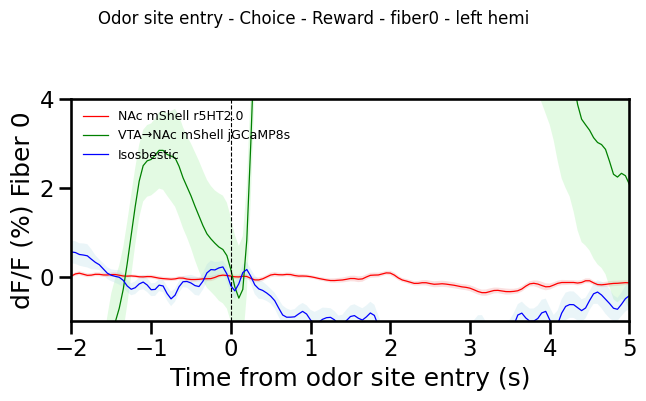

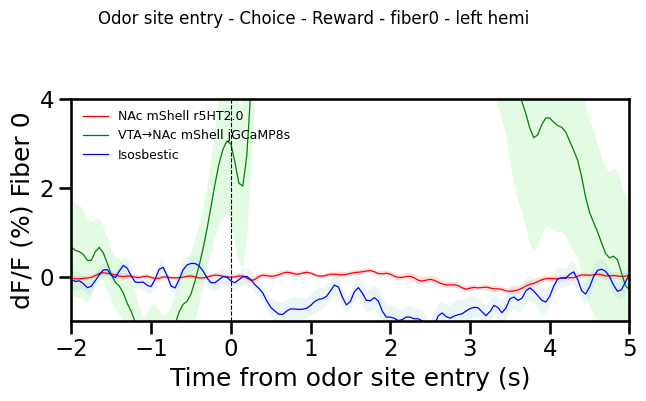

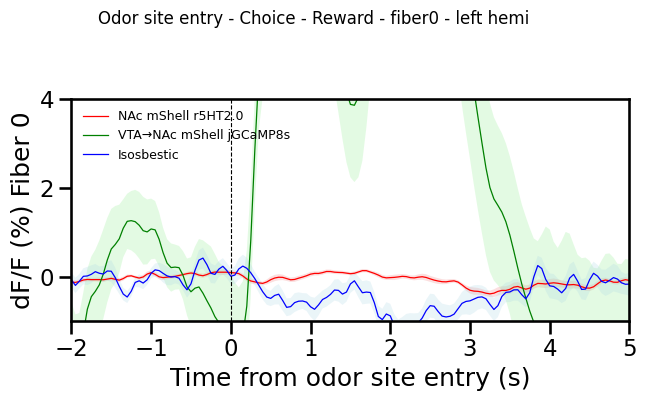

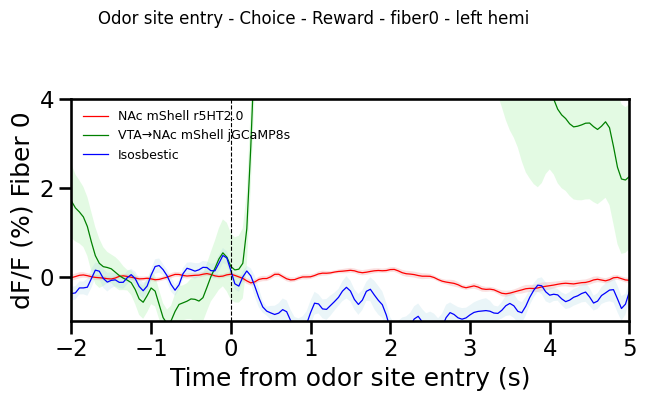

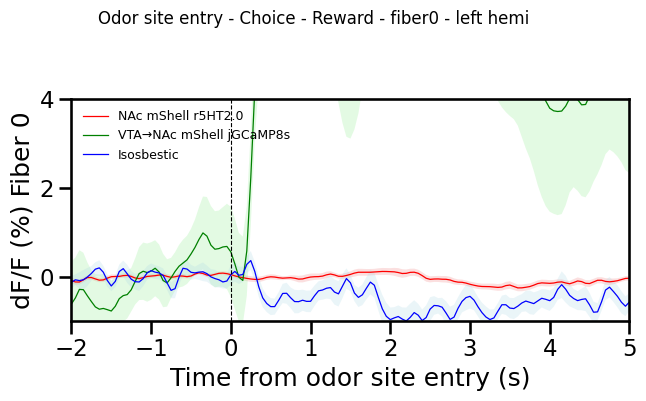

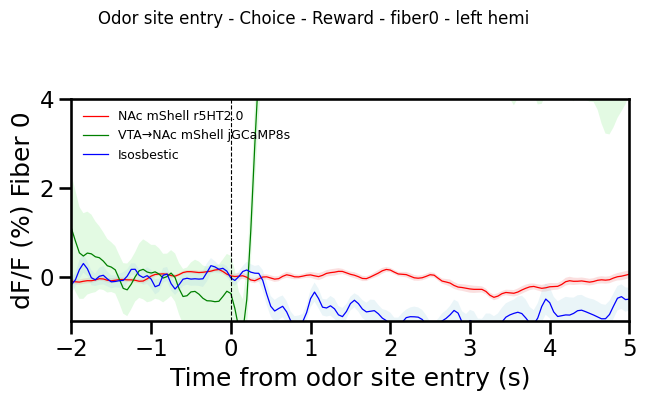

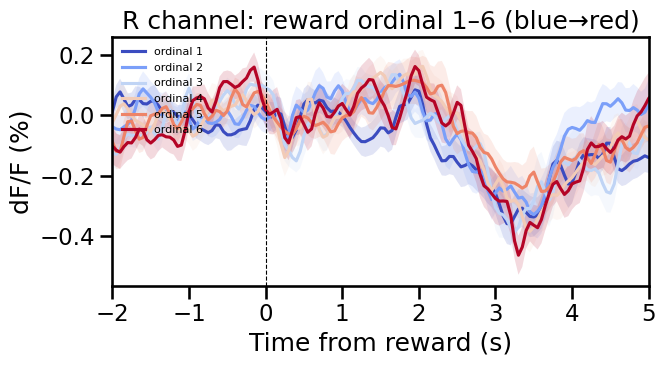

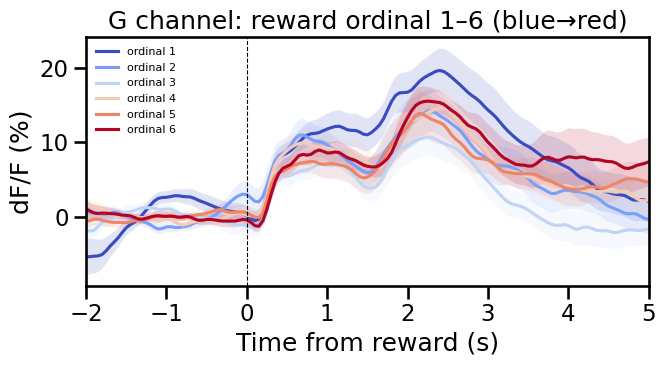

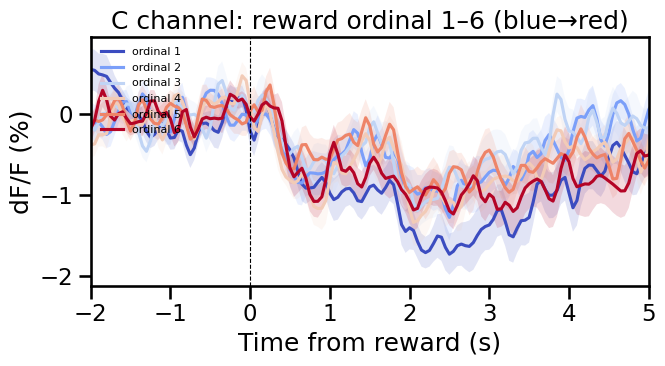

In [244]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def all_epochs_only_reward_ordinal(all_epochs, *, alignment="OdorSite", ordinal=1, is_reward=True):
    """
    Return a copy of all_epochs where only reward events with reward-ordinal==ordinal
    remain labeled as is_reward==True (others set False), so get_start_frames selects them.
    Uses patch_number + site_number columns already present.
    """
    ae = all_epochs.copy()

    align_cfg = ALIGNMENT_CFG[alignment]
    epoch_label = align_cfg["epoch_label"]

    # all rewarded choice events for this alignment
    mask_all = (
        (ae["label"] == epoch_label)
        & (ae["is_choice"].astype(bool))
        & (ae["is_reward"].astype(bool) == bool(is_reward))
    )

    # compute ordinal among *rewarded* events within each patch_number
    ev = ae.loc[mask_all, ["patch_number", "site_number"]].copy()
    ev = ev.sort_index()
    ev["reward_ordinal"] = ev.groupby("patch_number").cumcount() + 1

    mask_k = mask_all.copy()
    mask_k.loc[mask_all] = (ev["reward_ordinal"] == ordinal).values

    # For non-selected rewarded events, flip is_reward so get_start_frames ignores them
    ae.loc[mask_all & (~mask_k), "is_reward"] = (not is_reward)

    return ae, mask_k

# run ordinal 1-3
ordinal_results = {}

for k in [1, 2, 3, 4, 5, 6]:
    ae_k, mask_k = all_epochs_only_reward_ordinal(all_epochs, alignment="OdorSite", ordinal=k, is_reward=True)
    n_events = int(mask_k.sum())
    print(f"ordinal {k}: n_events = {n_events}")

    if n_events == 0:
        continue  # nothing to compute/plot for this ordinal

    res = plot_photometry_psth(
        ae_k,
        data1,
        Ctrl_dF_F,
        G_dF_F,
        R_dF_F,
        Roi2Vis,
        alignment="OdorSite",
        is_reward=True,
        subject=subject_ID,        # <-- set yours
        hemisphere="Left",    # <-- set yours
        save_fig=False,
        xlims=(-2, 5),
        ylims=(-1, 4),
    )
    ordinal_results[k] = res


# ---- extract average traces (mean across trials) ----
# psth_* shape: (time, 1, trials)
t_rel = ordinal_results[1]["t_rel"]

avg = {}
sem = {}
for k, res in ordinal_results.items():
    avg[k] = {}
    sem[k] = {}
    for ch_name, psth in [("R", res["psth_R"]), ("G", res["psth_G"]), ("C", res["psth_C"])]:
        P = psth[:, 0, :]  # (time, trials)
        avg[k][ch_name] = np.nanmean(P, axis=1)
        sem[k][ch_name] = np.nanstd(P, axis=1, ddof=1) / np.sqrt(np.sum(~np.isnan(P), axis=1))

# ---- plot overlays: ordinal #1..#6 for each channel ----
import matplotlib as mpl
import matplotlib.pyplot as plt

ordinals_to_plot = [1, 2, 3, 4, 5, 6]

# Blue -> Red gradient (use "coolwarm"; you can also try "bwr")
cmap = mpl.cm.get_cmap("coolwarm")
norm = mpl.colors.Normalize(vmin=min(ordinals_to_plot), vmax=max(ordinals_to_plot))

for ch_name in ["R", "G", "C"]:
    plt.figure(figsize=(7, 4))

    for k in ordinals_to_plot:
        if k not in avg:
            continue

        color = cmap(norm(k))
        plt.plot(t_rel, avg[k][ch_name], color=color, label=f"ordinal {k}")
        plt.fill_between(
            t_rel,
            avg[k][ch_name] - sem[k][ch_name],
            avg[k][ch_name] + sem[k][ch_name],
            color=color,
            alpha=0.15,
            linewidth=0,
        )

    plt.xlim(-2, 5)     # seconds around reward
    #plt.ylim(-1, 3)     # dF/F (%) — pick what makes sense for your scale
    plt.axvline(0, color="k", ls="--", lw=0.8)
    plt.xlabel("Time from reward (s)")
    plt.ylabel("dF/F (%)")
    plt.title(f"{ch_name} channel: reward ordinal 1–6 (blue→red)")
    plt.legend(frameon=False, ncol=1, loc="upper left",fontsize=8)
    plt.tight_layout()
    plt.show()



In [239]:
pd.set_option('display.max_columns',None)
all_epochs

,label,start_position,length,friction,patch_number,patch_label,odor_label,site_number,stop_time,choice_cue_time,reward_onset_time,succesful_wait_time,is_choice,is_reward,reward_amount,reward_probability,reward_available,odor_sites,collected,depleted,last_visit,last_site,cumulative_rewards,consecutive_rewards,cumulative_failures,consecutive_failures,after_choice_cumulative_rewards,duration_epoch,patch_onset,time_since_entry,exit_epoch,skipped_count
Time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1.551313e+06,InterPatch,8.599880,248.690787,0.0,0,PatchZB,Dipropyl sulfide,NaN,1.551323e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.713984,1.551323e+06,-9.713984,0.000000,NaN
1.551323e+06,InterSite,257.290667,50.684817,0.0,0,PatchZB,Dipropyl sulfide,NaN,1.551326e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.980000,1.551323e+06,0.000000,2.980000,NaN
1.551326e+06,OdorSite,307.975484,50.000000,0.0,0,PatchZB,Dipropyl sulfide,0.0,1.551331e+06,1.551326e+06,1.551327e+06,1.551327e+06,True,True,5.0,0.90000,50.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.044000,1.551323e+06,2.980000,8.024000,0.0
1.551331e+06,InterSite,357.975484,41.770291,0.0,0,PatchZB,Dipropyl sulfide,NaN,1.551333e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.900000,1.551323e+06,8.024000,10.924000,NaN
1.551333e+06,OdorSite,399.745775,50.000000,0.0,0,PatchZB,Dipropyl sulfide,1.0,1.551336e+06,1.551334e+06,1.551334e+06,1.551334e+06,True,True,5.0,0.87768,45.0,1.0,5.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,2.932000,1.551323e+06,10.924000,13.856000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1.554254e+06,OdorSite,37359.414436,50.000000,0.0,30,PatchZB,Dipropyl sulfide,0.0,1.554264e+06,1.554255e+06,1.554256e+06,1.554256e+06,True,True,5.0,0.90000,50.0,303.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,10.470016,1.554252e+06,2.274016,12.744032,0.0
1.554264e+06,InterSite,37409.414436,91.586932,0.0,30,PatchZB,Dipropyl sulfide,NaN,1.554277e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.140000,1.554252e+06,12.744032,24.884032,NaN
1.554277e+06,OdorSite,37501.001368,50.000000,0.0,30,PatchZB,Dipropyl sulfide,1.0,1.554280e+06,NaN,NaN,NaN,False,False,5.0,0.87768,45.0,304.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.592000,1.554252e+06,24.884032,28.476032,0.0


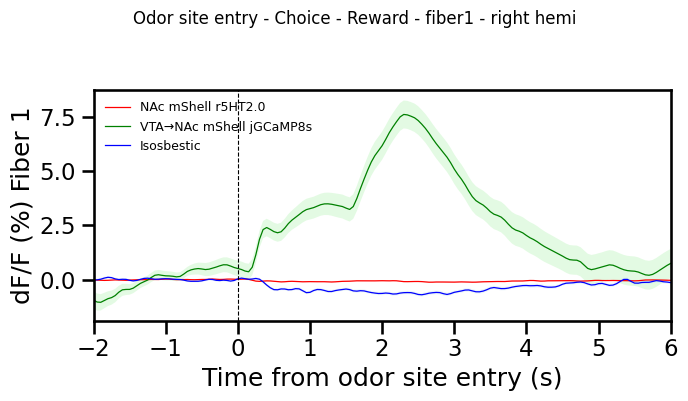

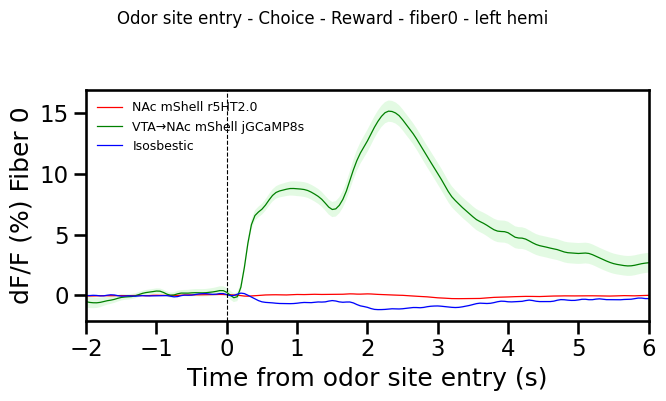

In [240]:
#Time lag analysis

# 1) Run your existing PSTH function around some event alignment (e.g., rewards or InterSite)
res1 = plot_photometry_psth(
    all_epochs,
    data1,
    Ctrl_dF_F,
    G_dF_F,
    R_dF_F,
    Roi2Vis,
    alignment="OdorSite",   # or "InterSite" depending on your ALIGNMENT_CFG
    is_reward=True,         # set appropriately for the alignment
    subject=subject_ID,         # yours
    hemisphere="Right",     # yours
    save_fig=False,
    xlims=(-2, 6),
    ylims=None,
)

res2 = plot_photometry_psth(
    all_epochs,
    data1,
    Ctrl_dF_F,
    G_dF_F,
    R_dF_F,
    Roi2Vis,
    alignment="OdorSite",   # or "InterSite" depending on your ALIGNMENT_CFG
    is_reward=True,         # set appropriately for the alignment
    subject=subject_ID,         # yours
    hemisphere="Left",     # yours
    save_fig=False,
    xlims=(-2, 6),
    ylims=None,
)

# 2) Grab t_rel
t_rel = res1["t_rel"]  # shape (time,)

# 3) Extract trial-by-trial traces for the specific ROIs you care about
#    Shapes here: (time, trials)
red_roi1_trials   = res1["psth_R"]   # ROI=1
green_roi0_trials = res2["psth_G"]   # ROI=0

# 4) Compute mean PSTHs (for plotting/cross-corr later)
red_mean   = np.nanmean(red_roi1_trials, axis=1)
green_mean = np.nanmean(green_roi0_trials, axis=1)

red_trials: (240, 184) red_mean: (240,)
green_trials: (240, 184) green_mean: (240,)


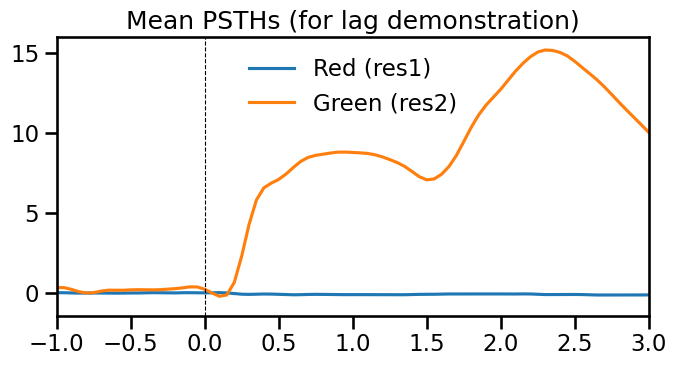

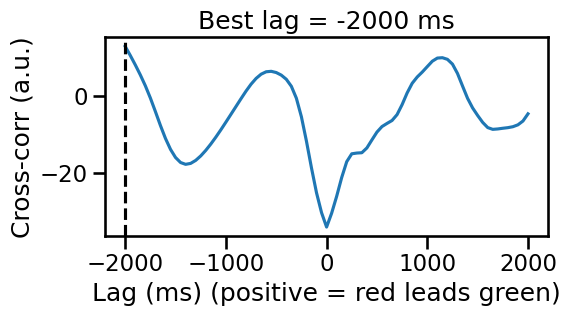

In [241]:
import numpy as np
import matplotlib.pyplot as plt

# given shape (time, 1, trials)
red_trials   = red_roi1_trials[:, 0, :]     # -> (time, trials)
green_trials = green_roi0_trials[:, 0, :]   # -> (time, trials)

# mean trace across trials -> (time,)
red_mean   = np.nanmean(red_trials, axis=1)
green_mean = np.nanmean(green_trials, axis=1)

print("red_trials:", red_trials.shape, "red_mean:", red_mean.shape)
print("green_trials:", green_trials.shape, "green_mean:", green_mean.shape)


def best_lag_xcorr(x, y, t_rel, max_lag_s=2.0, win=(0, 3.0)):
    dt = float(np.median(np.diff(t_rel)))
    mask = (t_rel >= win[0]) & (t_rel <= win[1])
    x = x[mask]; y = y[mask]

    x = (x - np.nanmean(x)) / (np.nanstd(x) + 1e-12)
    y = (y - np.nanmean(y)) / (np.nanstd(y) + 1e-12)
    x = np.nan_to_num(x, nan=0.0)
    y = np.nan_to_num(y, nan=0.0)

    c = np.correlate(x, y, mode="full")
    lags = np.arange(-len(x)+1, len(x)) * dt

    keep = (lags >= -max_lag_s) & (lags <= max_lag_s)
    c = c[keep]; lags = lags[keep]
    lag = lags[np.argmax(c)]
    return lag, lags, c

lag_s, lags, cc = best_lag_xcorr(red_mean, green_mean, t_rel, max_lag_s=2.0, win=(0,3.0))

# Overlay means
plt.figure(figsize=(7,4))
plt.plot(t_rel, red_mean, label="Red (res1)")
plt.plot(t_rel, green_mean, label="Green (res2)")
plt.axvline(0, color="k", ls="--", lw=0.8)
plt.xlim(-1, 3)
plt.legend(frameon=False)
plt.title("Mean PSTHs (for lag demonstration)")
plt.tight_layout()
plt.show()

# Cross-corr curve
plt.figure(figsize=(6,3.5))
plt.plot(lags*1000, cc)
plt.axvline(lag_s*1000, ls="--", color="k")
plt.xlabel("Lag (ms) (positive = red leads green)")
plt.ylabel("Cross-corr (a.u.)")
plt.title(f"Best lag = {lag_s*1000:.0f} ms")
plt.tight_layout()
plt.show()


In [242]:
all_epochs

,label,start_position,length,friction,patch_number,patch_label,odor_label,site_number,stop_time,choice_cue_time,reward_onset_time,succesful_wait_time,is_choice,is_reward,reward_amount,reward_probability,reward_available,odor_sites,collected,depleted,last_visit,last_site,cumulative_rewards,consecutive_rewards,cumulative_failures,consecutive_failures,after_choice_cumulative_rewards,duration_epoch,patch_onset,time_since_entry,exit_epoch,skipped_count
Time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1.551313e+06,InterPatch,8.599880,248.690787,0.0,0,PatchZB,Dipropyl sulfide,NaN,1.551323e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.713984,1.551323e+06,-9.713984,0.000000,NaN
1.551323e+06,InterSite,257.290667,50.684817,0.0,0,PatchZB,Dipropyl sulfide,NaN,1.551326e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.980000,1.551323e+06,0.000000,2.980000,NaN
1.551326e+06,OdorSite,307.975484,50.000000,0.0,0,PatchZB,Dipropyl sulfide,0.0,1.551331e+06,1.551326e+06,1.551327e+06,1.551327e+06,True,True,5.0,0.90000,50.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.044000,1.551323e+06,2.980000,8.024000,0.0
1.551331e+06,InterSite,357.975484,41.770291,0.0,0,PatchZB,Dipropyl sulfide,NaN,1.551333e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.900000,1.551323e+06,8.024000,10.924000,NaN
1.551333e+06,OdorSite,399.745775,50.000000,0.0,0,PatchZB,Dipropyl sulfide,1.0,1.551336e+06,1.551334e+06,1.551334e+06,1.551334e+06,True,True,5.0,0.87768,45.0,1.0,5.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,2.932000,1.551323e+06,10.924000,13.856000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1.554254e+06,OdorSite,37359.414436,50.000000,0.0,30,PatchZB,Dipropyl sulfide,0.0,1.554264e+06,1.554255e+06,1.554256e+06,1.554256e+06,True,True,5.0,0.90000,50.0,303.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,10.470016,1.554252e+06,2.274016,12.744032,0.0
1.554264e+06,InterSite,37409.414436,91.586932,0.0,30,PatchZB,Dipropyl sulfide,NaN,1.554277e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.140000,1.554252e+06,12.744032,24.884032,NaN
1.554277e+06,OdorSite,37501.001368,50.000000,0.0,30,PatchZB,Dipropyl sulfide,1.0,1.554280e+06,NaN,NaN,NaN,False,False,5.0,0.87768,45.0,304.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.592000,1.554252e+06,24.884032,28.476032,0.0


In [246]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# USER SETTINGS
# ============================
ROI_IDX = 0
ODORS = ["odor_90", "odor_60"]
XLIMS = (-2, 5)
YLIMS = None
SUBJECT = subject_ID
HEMISPHERE = "Left"

# ============================
# Helpers
# ============================
def odor_mask_from_patch_label(ae: pd.DataFrame, odor_name: str) -> pd.Series:
    if "patch_label" not in ae.columns:
        raise KeyError("Expected odor identity in all_epochs['patch_label'], but that column is missing.")
    return ae["patch_label"].astype(str) == odor_name

def first_odorsite_mask(ae: pd.DataFrame) -> pd.Series:
    """
    True for the first OdorSite row in each patch.
    Uses site_number if present; otherwise uses earliest time in patch for OdorSite rows.
    Returns a boolean Series indexed like ae.index.
    """
    if "patch_number" not in ae.columns:
        raise KeyError("all_epochs must contain 'patch_number'.")

    odor_rows = (ae["label"] == "OdorSite") & ae["patch_number"].notna()
    out = pd.Series(False, index=ae.index)

    if "site_number" in ae.columns:
        mins = ae.loc[odor_rows].groupby("patch_number")["site_number"].transform("min")
        out.loc[odor_rows] = (ae.loc[odor_rows, "site_number"] == mins).values
        return out

    # fallback: earliest OdorSite timestamp per patch
    tmp = ae.loc[odor_rows, ["patch_number"]].copy()
    tmp["t"] = ae.loc[odor_rows].index.values.astype(float)
    tmin = tmp.groupby("patch_number")["t"].transform("min")
    out.loc[odor_rows] = (tmp["t"] == tmin).values
    return out

def to_time_by_trials(psth, roi_idx=0):
    psth = np.asarray(psth)
    if psth.ndim == 2:
        return psth
    if psth.ndim == 3:
        return psth[:, roi_idx, :]
    raise ValueError(f"Unexpected PSTH shape: {psth.shape}")

# ============================
# Main
# Align to 1st OdorSite in patch
# Split patches by patch_label (odor_90 / odor_60)
# Overlay: patches-with-reward vs patches-without-reward
# ============================
for odor_name in ODORS:
    ae = all_epochs.sort_index().copy()

    # Restrict to this odor
    m_odor = odor_mask_from_patch_label(ae, odor_name)

    # Identify first OdorSite in each patch (within this odor)
    m_first_all = first_odorsite_mask(ae)
    m_first = m_first_all & m_odor

    # Compute patch_has_reward for this odor (any rewarded OdorSite row in the patch)
    m_reward_events = (
        (ae["label"] == "OdorSite") &
        ae["is_reward"].astype(bool) &
        m_odor &
        ae["patch_number"].notna()
    )
    patch_has_reward = (ae.loc[m_reward_events]
                        .groupby("patch_number")
                        .size() > 0)  # Series indexed by patch_number

    # Keep ONLY first OdorSite rows as label == "OdorSite" for alignment
    ae.loc[(ae["label"] == "OdorSite") & (~m_first), "label"] = "OdorSite_other"

    # For the first OdorSite events, define group membership by patch_has_reward
    first_patch_nums = ae.loc[m_first, "patch_number"].astype(int)
    first_is_rewarded_patch = first_patch_nums.map(patch_has_reward).fillna(False).astype(bool).to_numpy()


    # --- Encode group membership into is_reward on the FIRST OdorSite rows (single DF) ---
    ae_one = ae.copy()
    ae_one.loc[m_first, "is_reward"] = first_is_rewarded_patch  # True=rewared patch, False=unrewarded patch

    # Debug prints (optional)
    n_first = int(m_first.sum())
    n_rew = int(np.sum(first_is_rewarded_patch))
    n_unr = int(np.sum(~first_is_rewarded_patch))
    print(f"{odor_name}: first OdorSite events = {n_first} | rewarded patches = {n_rew} | unrewarded patches = {n_unr}")

    # --- Run PSTH: now titles and labels are semantically correct ---
    res_rew = plot_photometry_psth(
        ae_one, data1, Ctrl_dF_F, G_dF_F, R_dF_F, Roi2Vis,
        alignment="OdorSite", is_reward=True,
        subject=SUBJECT, hemisphere=HEMISPHERE,
        save_fig=False, xlims=XLIMS, ylims=YLIMS,
    )

    res_unr = plot_photometry_psth(
        ae_one, data1, Ctrl_dF_F, G_dF_F, R_dF_F, Roi2Vis,
        alignment="OdorSite", is_reward=False,
        subject=SUBJECT, hemisphere=HEMISPHERE,
        save_fig=False, xlims=XLIMS, ylims=YLIMS,
    )


    # Extract green channel trials at ROI_IDX and overlay
    t_rel = res_rew["t_rel"]
    g_rew = to_time_by_trials(res_rew["psth_G"], roi_idx=ROI_IDX)
    g_unr = to_time_by_trials(res_unr["psth_G"], roi_idx=ROI_IDX)

    plt.figure(figsize=(8,4))
    plot_mean_sem(t_rel, g_rew, "g", "lightgreen", f"{odor_name}: patches w/ reward (n={g_rew.shape[1]})")
    plot_mean_sem(t_rel, g_unr, "k", "0.7",       f"{odor_name}: patches w/o reward (n={g_unr.shape[1]})")
    plt.axvline(0, color="k", ls="--", lw=0.8)
    plt.xlim(*XLIMS)
    plt.title(f"Aligned to 1st OdorSite — {odor_name} — Green ROI {ROI_IDX}\nPatches with reward vs without reward")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


odor_90: first OdorSite events = 0 | rewarded patches = 0 | unrewarded patches = 0


ValueError: No events given.